In [1]:
import dataclasses
import jax
from openpi.models import model as _model
from openpi.policies import policy_config as _policy_config
from openpi.training import config as _config
from openpi.training import data_loader as _data_loader
import pandas as pd

/iris/u/jrpan/miniconda3/envs/openpi311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_pickle("/iris/u/jrpan/openpi/subtask_prediction_df_16_frames_v2_5.pkl")
example = df.iloc[0].to_dict()
if 'subtask_target' in example:
    print(example['subtask_target'])
    del example['subtask_target']

pick up the purple marker and put it in the white bin


In [1]:
# config_subtask_only = _config.get_config("pi05_cotrain_subtask_only")
# checkpoint_dir_subtask_only = "/iris/u/jrpan/openpi/checkpoints/pi05_cotrain_subtask_only/pi05_cotrain_subtask_0822/3000"
# policy_subtask_only = _policy_config.create_trained_policy(config_subtask_only, checkpoint_dir_subtask_only, task="subtask_pred")
# result_subtask_only = policy_subtask_only.infer_subtask(example)
# print("Result: ", result_subtask_only)
# # free up memory.
# del policy_subtask_only

In [3]:
config = _config.get_config("pi05_cotrain")
checkpoint_dir = "/iris/u/jrpan/openpi/checkpoints/pi05_cotrain/pi05_cotrain_full_0820/9000"
policy = _policy_config.create_trained_policy(config, checkpoint_dir, task="subtask_pred")
result = policy.infer_subtask(example)
print("Result: ", result)

----------STEP---------- 0
----------GENERATED TOKENS---------- 1
----------STEP---------- 1
----------LAST TOKEN---------- [[908]]
----------TOKEN OUT---------- (1, 1, 2048)
----------CURRENT CACHE---------- (18, 1, 4497, 1, 256)
----------GENERATED TOKENS---------- 2
----------STEP---------- 2
----------LAST TOKEN---------- [[573]]
----------TOKEN OUT---------- (1, 1, 2048)
----------CURRENT CACHE---------- (18, 1, 4498, 1, 256)
----------GENERATED TOKENS---------- 3
----------STEP---------- 3
----------LAST TOKEN---------- [[15811]]
----------TOKEN OUT---------- (1, 1, 2048)
----------CURRENT CACHE---------- (18, 1, 4499, 1, 256)
----------GENERATED TOKENS---------- 4
----------STEP---------- 4
----------LAST TOKEN---------- [[24416]]
----------TOKEN OUT---------- (1, 1, 2048)
----------CURRENT CACHE---------- (18, 1, 4500, 1, 256)
----------GENERATED TOKENS---------- 5
----------STEP---------- 5
----------LAST TOKEN---------- [[578]]
----------TOKEN OUT---------- (1, 1, 2048)
-----

### compute_subtask_loss

pick up the purple marker and put it in the white bin


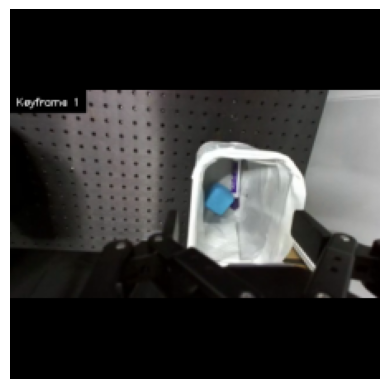

In [5]:
import jax.numpy as jnp
import numpy as np
from matplotlib import pyplot as plt
df = pd.read_pickle("/iris/u/jrpan/openpi/subtask_prediction_df_16_frames_v2_5.pkl")
example = df.iloc[0].to_dict()
if 'subtask_target' in example:
    print(example['subtask_target'])

inputs = policy._input_transform(example)
plt.imshow(inputs['image']['keyframe_1'])
plt.axis('off')
plt.show()

inputs = jax.tree.map(lambda x: jnp.asarray(x)[np.newaxis, ...], inputs)
observation = _model.Observation.from_dict(inputs)



In [7]:
from pathlib import Path
from openpi.models import tokenizer as _tokenizer        
from openpi.models import tokenizer as _tokenizer        
key = jax.random.key(0)
model = config.model.load(_model.restore_params(Path(checkpoint_dir) / "params"))

loss, predicted_tokens, target_mask = model.compute_subtask_loss(key, observation)
print(loss)
paligemma_tokenizer = _tokenizer.PaligemmaTokenizer()
valid_tokens = predicted_tokens[target_mask != 0]
decoded_text = paligemma_tokenizer._tokenizer.decode(valid_tokens.tolist())
print(decoded_text)

Exception: Encountered error while reading array index: (slice(0, 27, 1), slice(0, 1152, 1), slice(0, 4304, 1)). See full TensorStore details: <bound method PyCapsule.spec of TensorStore({
  'context': {
    'cache_pool': {},
    'cache_pool#ocdbt': {'total_bytes_limit': 100000000},
    'data_copy_concurrency': {},
    'file_io_concurrency': {'limit': 128},
    'file_io_locking': {},
    'file_io_memmap': False,
    'file_io_sync': True,
    'ocdbt_coordinator': {},
  },
  'driver': 'zarr',
  'dtype': 'float32',
  'fill_missing_data_reads': False,
  'kvstore': {
    'base': {
      'driver': 'file',
      'path': '/iris/u/jrpan/openpi/checkpoints/pi05_cotrain/pi05_cotrain_full_0820/9000/params/',
    },
    'cache_pool': 'cache_pool#ocdbt',
    'config': {
      'compression': {'id': 'zstd'},
      'max_decoded_node_bytes': 100000000,
      'max_inline_value_bytes': 1024,
      'uuid': 'b1c3f28728dc71693f79a5d45050a573',
      'version_tree_arity_log2': 4,
    },
    'driver': 'ocdbt',

pick up the purple marker and put it in the white bin



In [64]:
 # Reduce the batch size to reduce memory usage.
config = dataclasses.replace(config, subtask_batch_size=2)

# Load a single batch of data. This is the same data that will be used during training.
# NOTE: In order to make this example self-contained, we are skipping the normalization step
# since it requires the normalization statistics to be generated using `compute_norm_stats`.
loader = _data_loader.create_data_loader(config, num_batches=1, skip_norm_stats=True)
obs, act = next(iter(loader))

# Sample actions from the model.
loss = model.compute_subtask_loss(key, obs)

# Delete the model to free up memory.
del model

print("Loss shape:", loss.shape)

TRAIN DATASET META

LeRobotDatasetMetadata({
    Repository ID: 'jennypan00/pi_ft_droid_exclude_01_pct_vel_norm_train',
    Total episodes: '242',
    Total frames: '20685',
    Features: '['exterior_image_1_left', 'wrist_image_left', 'joint_position', 'gripper_position', 'prompt', 
'actions', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']',
})',

TypeError: stack(): argument 'tensors' (position 1) must be tuple of Tensors, not Column